# CIGALE + TAMIS for one COSMOS2020 galaxy

This notebook fits the representative object saved by notebook 00. It uses the same
delayed-tau CIGALE model as the catalog MAF tutorial, but performs an object-specific
posterior calculation with CompoSED's self-contained TAMIS implementation.
Because every prior in this example is continuous, the mixed proposal has
no categorical block and reduces to ordinary continuous TAMIS.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys
import numpy as np

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "composed").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
DATA_PATH = REPO_ROOT / "notebooks/tutorials/data/cosmos2020_ugrizYJH_100k.npz"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 00_prepare_cosmos2020_ugrizYJH.ipynb first.")

with np.load(DATA_PATH, allow_pickle=False) as catalog:
    flux = catalog["flux_maggies"]
    sigma = catalog["sigma_maggies"]
    z_reference = catalog["lp_zbest"]
    mass_reference = catalog["lp_mass_med"]
    sfr_reference = catalog["lp_sfr_med"]
    dust_reference = catalog["lp_dust"]
    BAND_NAMES = tuple(catalog["band_names"].astype(str))
    FILTER_NAMES = tuple(catalog["sedpy_filter_names"].astype(str))
    SINGLE_OBJECT = int(catalog["single_object_position"])

print(f"Loaded {flux.shape[0]:,} galaxies in {flux.shape[1]} bands")
print("Single tutorial object:", SINGLE_OBJECT, "z_ref=", z_reference[SINGLE_OBJECT])

from sedpy.observate import load_filters
from composed.filters import FilterSet

filters = FilterSet(load_filters(list(FILTER_NAMES)), names=BAND_NAMES)


Loaded 100,000 galaxies in 8 bands
Single tutorial object: 36096 z_ref= 1.0001


In [2]:
from composed import DelayedTauSFH, EmpiricalPhotometricNoise, Gaussian, Problem, SEDDataset, UniformPrior
from composed.backends.cigale import build_cigale_backend_and_parameter_space

sfh = DelayedTauSFH(age="age_fraction", age_kind="fraction_of_universe", tau="tau_gyr")
modules = ["bc03", "nebular", "dustatt_modified_starburst", "redshifting"]
module_parameters = {
    "bc03": {"imf": 1, "metallicity": 0.02, "separation_age": 10},
    "nebular": {
        "logU": -2.0, "zgas": 0.019, "ne": 100.0, "f_esc": 0.0,
        "f_dust": 0.0, "lines_width": 300.0, "emission": True,
    },
    "dustatt_modified_starburst": {
        "E_BV_lines": {"range": [0.0, 0.8]}, "E_BV_factor": 0.44,
        "uv_bump_wavelength": 217.5, "uv_bump_width": 35.0,
        "uv_bump_amplitude": 0.0, "powerlaw_slope": 0.0,
        "Ext_law_emission_lines": 1, "Rv": 3.1, "filters": "B_B90 & V_B90",
    },
    "redshifting": {"redshift": {"range": [0.05, 5.0]}},
}
backend, parameters = build_cigale_backend_and_parameter_space(
    modules,
    module_parameters,
    additional_priors={
        "log10_mass": UniformPrior(6.0, 13.0),
        "age_fraction": UniformPrior(0.30, 0.95),
        "tau_gyr": UniformPrior(0.1, 8.0),
    },
    sfh=sfh,
    photometry_mode="sedpy",
    default_z_key="redshift",
)
FRACTIONAL_MODEL_ERROR = 0.05
sigma_effective = np.sqrt(sigma**2 + (FRACTIONAL_MODEL_ERROR * np.abs(flux))**2)
noise_model = EmpiricalPhotometricNoise(
    sigma, fractional_error=FRACTIONAL_MODEL_ERROR, band_names=BAND_NAMES, flux_unit="maggies"
)
data = SEDDataset(BAND_NAMES, flux[SINGLE_OBJECT], sigma_effective[SINGLE_OBJECT], flux_unit="maggies")
problem = Problem(backend, parameters, data, Gaussian(), filters=filters)


## Fit


In [3]:
from composed import (
    MixedTAMIS, fit, load_inference_result, posterior_summary, save_inference_result,
)

OUTPUT = REPO_ROOT / "outputs/tutorial_cigale_tamis_single"
if (OUTPUT / "inference_result.npz").exists():
    result = load_inference_result(OUTPUT)
    print("Loaded saved TAMIS fit")
else:
    result = fit(
        problem,
        MixedTAMIS(
            n_comp=6,
            T_max=50,
            n_per_iter=1000,
            var0=2.0,
            continuous_transform="auto",
        ),
        seed=61,
    )
    save_inference_result(result, OUTPUT)
tamis_meta = result.metadata.get("sampler_meta", {})
print("Final TAMIS adaptation beta:", np.asarray(tamis_meta.get("betas", [np.nan]))[-1])
print("Posterior-weight ESS:", 1.0 / np.sum(result.weights**2))
posterior_summary(result)


Loaded saved TAMIS fit
Final TAMIS adaptation beta: 0.724171595672626
Posterior-weight ESS: 4446.263105765427


{'log10_mass': {'q_lo': 10.01802982500188,
  'median': 10.082921275072819,
  'q_hi': 10.14615895211529,
  'map': 10.02804654752664},
 'age_fraction': {'q_lo': 0.4101213894598348,
  'median': 0.5585665913056911,
  'q_hi': 0.7555245652537386,
  'map': 0.4137784015753398},
 'tau_gyr': {'q_lo': 0.7265135978957962,
  'median': 1.475981507638735,
  'q_hi': 4.86126742005325,
  'map': 0.5743349298692471},
 'E_BV_lines': {'q_lo': 0.4010467949742786,
  'median': 0.6688730682458973,
  'q_hi': 0.7639825086696922,
  'map': 0.37469299804914125},
 'redshift': {'q_lo': 0.8766594550733141,
  'median': 0.9114881743451396,
  'q_hi': 0.949605018766365,
  'map': 0.91723925073427}}

## Posterior and posterior predictive SED


(<Figure size 800x330 with 1 Axes>,
 array([<Axes: xlabel='wavelength', ylabel='flux [photometry units]'>],
       dtype=object))

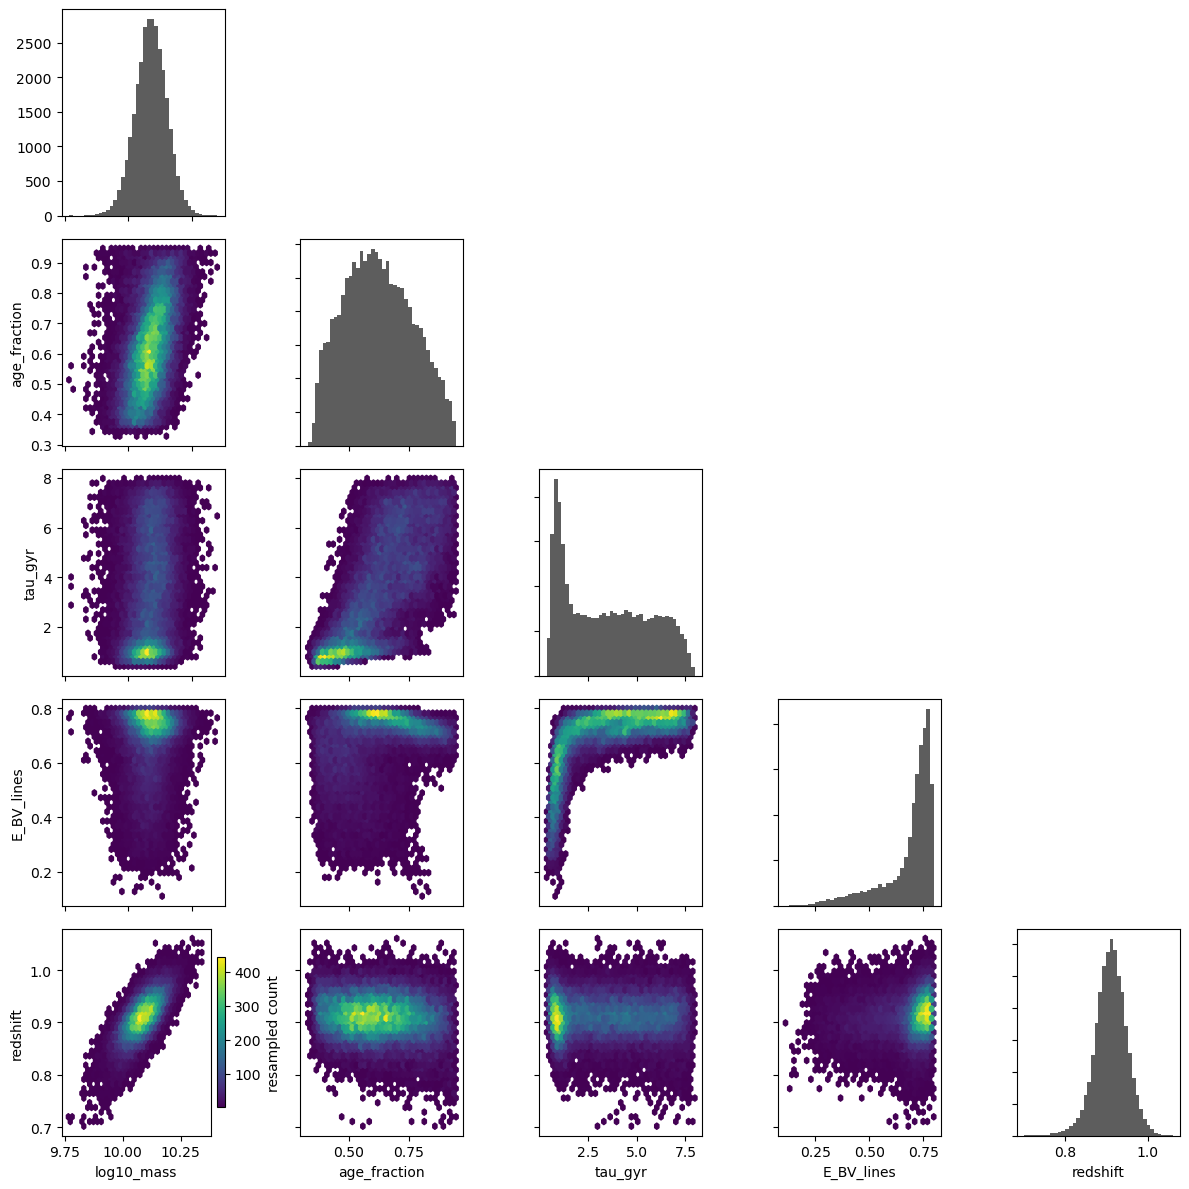

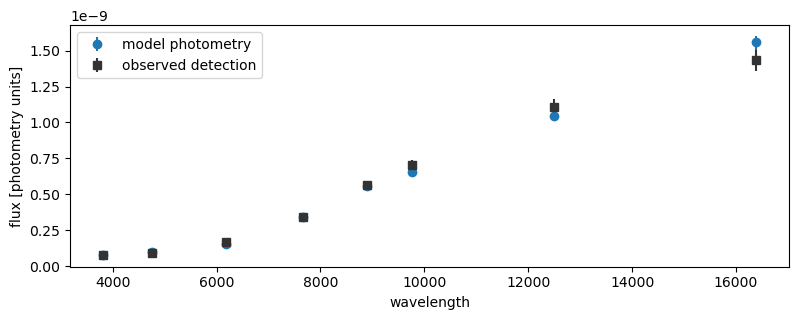

In [4]:
from composed.plot import plot_corner_hexbin, plot_posterior_predictive_sed

plot_corner_hexbin(result, max_points=30_000)
plot_posterior_predictive_sed(
    result, backend, parameters, photometry=data, filters=filters,
    n_draw=150, seed=62,
)


posterior median z, logM, logSFR: 0.9114881743451396 10.082921275072819 0.6544632278569995
LePhare reference: 1.0001 10.00341 1.09896


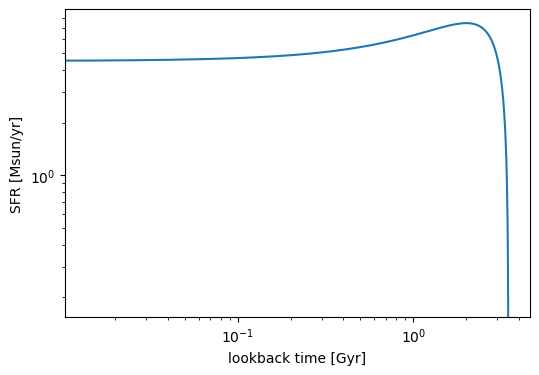

In [5]:
from composed import derive_sfh_quantities

median_params = parameters.to_dict(result.posterior_median)
derived = derive_sfh_quantities(backend, median_params, filters)
lookback = derived.time_gyr[-1] - derived.time_gyr
plt.figure(figsize=(6, 4))
plt.plot(lookback[::-1], derived.sfr_msun_per_yr[::-1])
plt.xscale("log"); plt.yscale("log")
plt.xlabel("lookback time [Gyr]"); plt.ylabel("SFR [Msun/yr]")
print("posterior median z, logM, logSFR:", median_params["redshift"], median_params["log10_mass"], derived.log10_sfr)
print("LePhare reference:", z_reference[SINGLE_OBJECT], mass_reference[SINGLE_OBJECT], sfr_reference[SINGLE_OBJECT])
